<a href="https://colab.research.google.com/github/vasanthakumar-saravanan/Hand-Cricket-Python/blob/main/Corporation_Alert_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import zipfile
import os

zip_path = "/content/Road Damage Dataset.zip"
extract_path = "/content/rdd"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted")

Dataset extracted


In [10]:
for root, dirs, files in os.walk("/content/rdd"):
    if "images" in root:
        print(root)

/content/rdd/data/images


In [11]:
import os

for root, dirs, files in os.walk("/content/rdd"):
    for f in files:
        if "annotation" in f.lower():
            print(os.path.join(root, f))

/content/rdd/data/annotations_coco.json


In [12]:
anno_path = "/content/rdd/data/annotations_coco.json"

In [13]:
import json

anno_path = "/content/rdd/data/annotations_coco.json"

with open(anno_path, "r") as f:
    coco = json.load(f)

print(coco.keys())

dict_keys(['images', 'annotations', 'categories'])


In [14]:
cat_map = {c["id"]: c["name"] for c in coco["categories"]}
img_map = {i["id"]: i["file_name"] for i in coco["images"]}

print(cat_map)

{0: 'pothole', 1: 'crack', 2: 'manhole'}


In [15]:
severity_map = {
    "crack": "low",
    "pothole": "high",
    "manhole": "high"
}

In [16]:
import os

base_out = "/content/severity_dataset"
os.makedirs(base_out + "/low", exist_ok=True)
os.makedirs(base_out + "/high", exist_ok=True)

print(os.listdir(base_out))

['low', 'high']


In [17]:
import shutil

img_base = "/content/rdd/data/images"

count = {"low": 0, "high": 0}

for ann in coco["annotations"]:
    cat_name = cat_map[ann["category_id"]]
    severity = severity_map.get(cat_name)

    if severity is None:
        continue

    img_name = img_map[ann["image_id"]]
    src = os.path.join(img_base, img_name)
    dst = os.path.join(base_out, severity, img_name)

    if os.path.exists(src):
        shutil.copy(src, dst)
        count[severity] += 1

print(count)

{'low': 2519, 'high': 2218}


In [18]:
print("LOW:", len(os.listdir("/content/severity_dataset/low")))
print("HIGH:", len(os.listdir("/content/severity_dataset/high")))

LOW: 1375
HIGH: 1318


In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    base_out,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training"
)

val_data = datagen.flow_from_directory(
    base_out,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation"
)
777
print(train_data.class_indices)

Found 2155 images belonging to 2 classes.
Found 538 images belonging to 2 classes.
{'high': 0, 'low': 1}


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential([
    Input(shape=(224,224,3)),

    Conv2D(32, 3, activation="relu"),
    MaxPooling2D(),

    Conv2D(64, 3, activation="relu"),
    MaxPooling2D(),

    Conv2D(128, 3, activation="relu"),
    MaxPooling2D(),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 24s 226ms/step - accuracy: 0.5042 - loss: 0.9258 - val_accuracy: 0.4888 - val_loss: 0.6944
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.5785 - loss: 0.6820 - val_accuracy: 0.4944 - val_loss: 0.7096
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 136ms/step - accuracy: 0.6338 - loss: 0.6509 - val_accuracy: 0.4926 - val_loss: 0.7173
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.6229 - loss: 0.6454 - val_accuracy: 0.5112 - val_loss: 0.7035
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.6453 - loss: 0.6244 - val_accuracy: 0.4814 - val_loss: 0.7386
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.6648 - loss: 0.6034 - val_accuracy: 0.4963 - val_loss: 0.7820
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step - accuracy: 0.6679 - loss: 0.5936 - val_accuracy: 0.5019 - val_loss: 0.8070
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 123ms/step - accuracy: 0.6751 - loss: 0.5713 - val_accuracy: 0

In [22]:
model.save("/content/pothole_severity_model.h5")

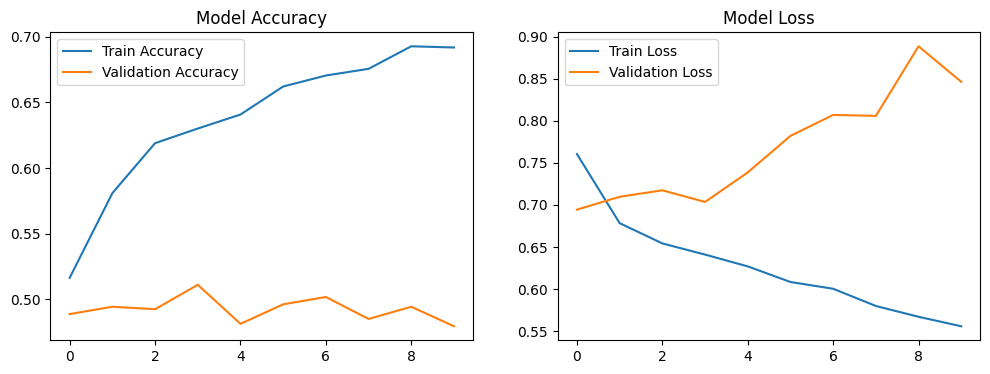

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")

# Loss graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Model Loss")

plt.show()

In [28]:
model.save("pothole_severity_model.h5")

In [27]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "test3.jpg"  # change if needed

img = image.load_img(img_path, target_size=(224,224))
img = image.img_to_array(img) / 255.0
img = np.expand_dims(img, axis=0)

prediction = model.predict(img)[0][0]
print("Confidence score:", prediction)

if prediction > 0.65:
    print("🟢 LOW severity (safe)")
elif prediction > 0.35:
    print("🟡 MEDIUM severity (review required)")
else:
    print("🔴 HIGH severity (urgent repair)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 847ms/step
Confidence score: 0.5155573
🟡 MEDIUM severity (review required)
